# Power Lognormal Distribution

The **Power Lognormal distribution** generalises the Lognormal by adding a power parameter p. Its hazard function is p times the Lognormal hazard — making it more flexible for reliability modeling where the standard Lognormal hazard shape (first increasing then decreasing) doesn't fit.

| Property | Value |
|---|---|
| **Parameters** | $p$ (power/shape, $p > 0$), $\sigma$ (scale-shape), $\mu$ (location), $B$ (scale) |
| **PDF** | $\displaystyle f(x) = \frac{p\,\phi(z)}{\sigma x}\,[\Phi(z)]^{p-1}$, where $z = \dfrac{\ln((x-\mu)/B)}{\sigma}$ |
| **CDF** | $F(x) = [\Phi(z)]^p$ |
| **Hazard** | $h(x) = p \times h_{\text{Lognormal}}(x)$ |
| **Special case** | $p=1 \to$ Standard Lognormal |
| **Use cases** | Reliability analysis with non-standard hazard shapes |
| **Note** | Requires MLE numerical optimisation; not in standard libraries |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Power Lognormal Distribution

### Panel 1 — PDF: $p$ Scales the Distribution
Each curve shows the manually-implemented **Power Lognormal PDF** $f(x) = p\,\phi(z)/(\sigma x)[\Phi(z)]^{p-1}$ for different $p$. At $p=1$ it reduces to the Lognormal; larger $p$ compresses the distribution toward smaller $x$ values.

### Panel 2 — CDF: $F(x) = [\Phi(\ln(x)/\sigma)]^p$
The **CDF** shows how $p$ controls probability accumulation. Higher $p$ shifts the mass toward smaller values; lower $p$ spreads it out more toward the right tail.

### Panel 3 — Hazard Function: Non-Monotone Shape
The **hazard function** $h(x) = p \times h_{\text{Lognormal}}(x)$ is non-monotone — it rises then falls — unlike the monotone Weibull hazard. This bathtub-like shape is useful for modeling mid-life failure patterns.


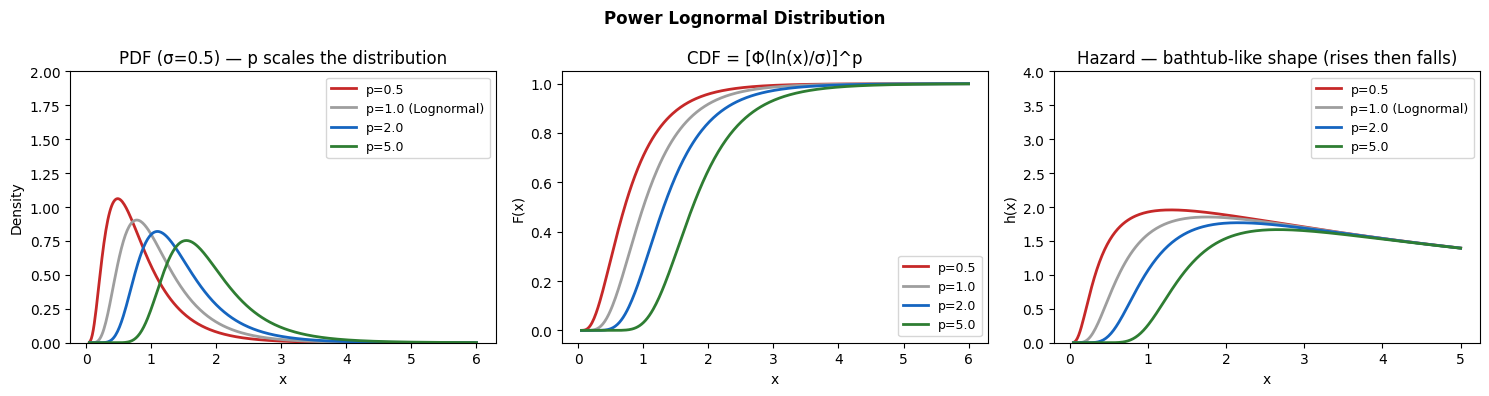

In [2]:
# Implement Power Lognormal manually (F(x) = Phi(z)^p, z=log(x)/sigma)
def power_lognormal_pdf(x, p, sigma, mu=0, B=1):
    z = (np.log((x - mu) / B)) / sigma
    phi = stats.norm.pdf(z)
    Phi = stats.norm.cdf(z)
    return p * phi / (sigma * (x - mu)) * Phi**(p-1)

def power_lognormal_cdf(x, p, sigma, mu=0, B=1):
    z = (np.log((x - mu) / B)) / sigma
    return stats.norm.cdf(z)**p

x = np.linspace(0.05, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Power Lognormal Distribution', fontsize=12, fontweight='bold')

sigma = 0.5

# PDF for varying p
for p, color, label in [(0.5, '#C62828', 'p=0.5'),
                         (1.0, '#9E9E9E', 'p=1.0 (Lognormal)'),
                         (2.0, '#1565C0', 'p=2.0'),
                         (5.0, '#2E7D32', 'p=5.0')]:
    y = power_lognormal_pdf(x, p=p, sigma=sigma)
    axes[0].plot(x, y, color=color, linewidth=2, label=label)
axes[0].set_title(f'PDF (σ={sigma}) — p scales the distribution')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.0)
axes[0].legend(fontsize=9)

# CDF
for p, color, label in [(0.5, '#C62828', 'p=0.5'), (1.0, '#9E9E9E', 'p=1.0'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    axes[1].plot(x, power_lognormal_cdf(x, p=p, sigma=sigma),
                 color=color, linewidth=2, label=label)
axes[1].set_title('CDF = [Φ(ln(x)/σ)]^p')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=9)

# Hazard functions (p × Lognormal hazard)
x_h = np.linspace(0.05, 5, 300)
for p, color, label in [(0.5, '#C62828', 'p=0.5'), (1.0, '#9E9E9E', 'p=1.0 (Lognormal)'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    pdf_vals = power_lognormal_pdf(x_h, p=p, sigma=sigma)
    cdf_vals = power_lognormal_cdf(x_h, p=p, sigma=sigma)
    sf_vals = 1 - cdf_vals
    h = np.where(sf_vals > 1e-10, pdf_vals / sf_vals, 0)
    axes[2].plot(x_h, h, color=color, linewidth=2, label=label)
axes[2].set_title('Hazard — bathtub-like shape (rises then falls)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('h(x)')
axes[2].set_ylim(0, 4)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

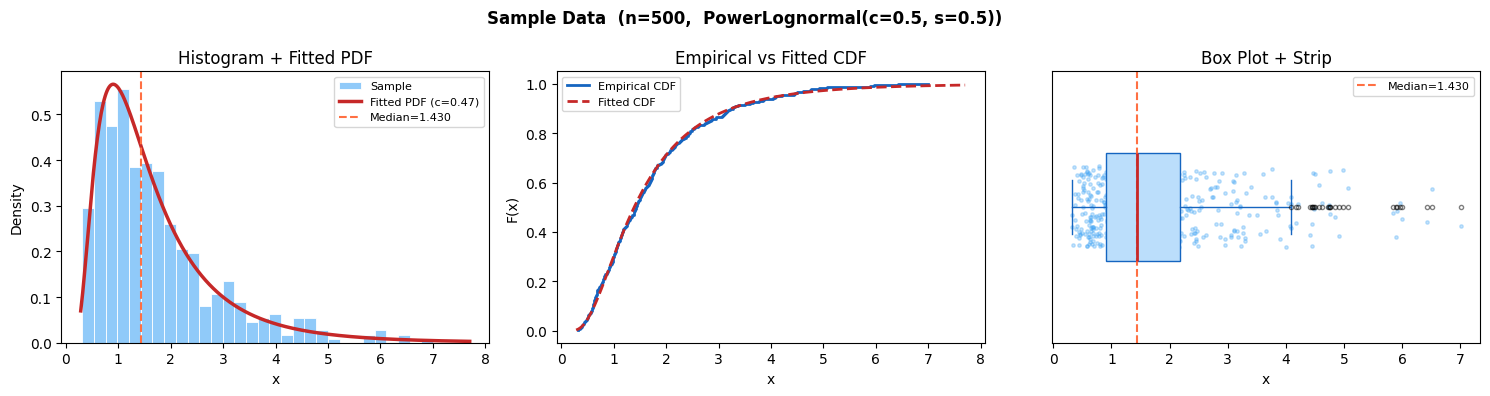

n=500  mean=1.7313  median=1.4304  std=1.1729  skew=1.5575  kurtosis=2.6908


In [3]:
# Sample data plots — PowerLognormal(c=0.5, s=0.5)
np.random.seed(42)
sample_d = stats.powerlognorm.rvs(c=0.5, s=0.5, size=500)
c_hat, s_hat, loc_hat, scale_hat = stats.powerlognorm.fit(sample_d, floc=0)
x_fit = np.linspace(max(sample_d.min() * 0.9, 0.01), sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  PowerLognormal(c=0.5, s=0.5))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.powerlognorm(c_hat, s_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (c={c_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.powerlognorm(c_hat, s_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **p=1** | Reduces to standard Lognormal |
| **Hazard** | Non-monotone (rises then falls) — useful for mid-life failure patterns |
| **p scales hazard** | $h_{\text{PowerLognormal}}(x) = p \times h_{\text{Lognormal}}(x)$ |
| **Two shape params** | $p$ and $\sigma$ together control the distribution shape — more flexible than Lognormal |
| **vs Weibull** | Weibull has monotone hazard; Power Lognormal can model non-monotone |
| **Software** | Manual implementation required — not in scipy/statsmodels directly |
